In [1]:
!pip install xgboost

Defaulting to user installation because normal site-packages is not writeable


In [2]:

# Then import the required libraries
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_auc_score
from xgboost import XGBClassifier
import pandas as pd

In [3]:
df = pd.read_csv('loan_features.csv')


In [4]:
# Prepare data
features = ['Total_Income', 'Income_Bucket', 'Avg_Area_Loan']

# Check if 'Property_Area' exists in the DataFrame, if not, remove it from the list
if 'Property_Area' in df.columns:
    X = pd.get_dummies(df[features + ['Credit_Category', 'Property_Area']])
else:
    # Use only columns that exist in the DataFrame
    # You might want to check if 'Credit_Category' exists as well
    if 'Credit_Category' in df.columns:
        X = pd.get_dummies(df[features + ['Credit_Category']])
    else:
        X = pd.get_dummies(df[features])

y = (df['Loan_Status'] == 'Y').astype(int)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [5]:
# Train model
model = XGBClassifier(
    random_state=42,
    base_score=0.5  # Set base_score to a value between 0 and 1
)
model.fit(X_train, y_train)

,objective,'binary:logistic'
,base_score,0.5
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [6]:
# Predict & Evaluate
y_pred = model.predict(X_test)
y_pred_proba = model.predict_proba(X_test)[:, 1]

In [7]:
print("AUC Score:", roc_auc_score(y_test, y_pred_proba))
print(classification_report(y_test, y_pred))

AUC Score: nan
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        99

    accuracy                           1.00        99
   macro avg       1.00      1.00      1.00        99
weighted avg       1.00      1.00      1.00        99



C:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_ranking.py:424: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(


In [8]:
import plotly.express as px
from plotly.subplots import make_subplots
import plotly.graph_objects as go



In [10]:
import pandas as pd

df_features = pd.read_csv('loan_features.csv')
print(df_features.head())

    Loan_ID  Total_Income  Income_Bucket Credit_Category  Avg_Area_Loan  \
0  LP002101       63337.0              1            Good     143.397260   
1  LP001585       51763.0              1            Good     143.397260   
2  LP001640       43897.0              1            Good     141.902174   
3  LP002422       37719.0              1            Good     141.902174   
4  LP001448       23803.0              1            Good     150.593103   

   Loan_Status  Category_Count  
0            1             380  
1            1             380  
2            1             380  
3            1             380  
4            1             380  


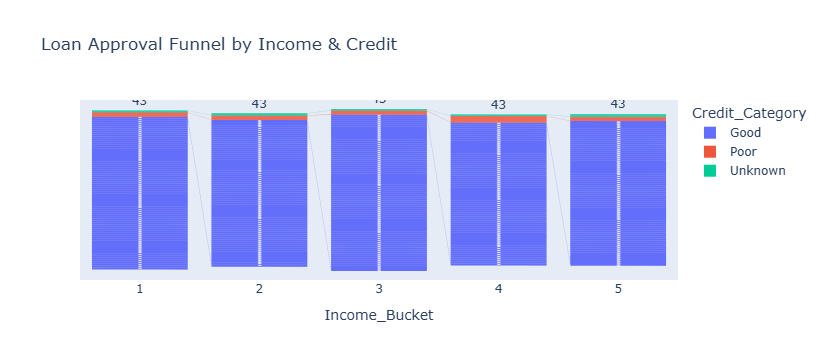

In [14]:
import plotly.express as px
from plotly.subplots import make_subplots
import plotly.graph_objects as go

# 1. Credit Risk Funnel
fig1 = px.funnel(df_features, x='Income_Bucket', y='Category_Count', 
                color='Credit_Category',
                title="Loan Approval Funnel by Income & Credit")
fig1.write_html('risk_funnel.html')
fig1.show()





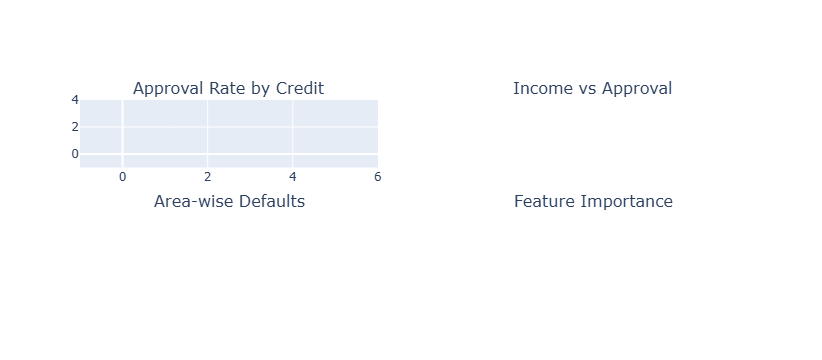

In [18]:
# 2. Feature Importance
importance_df = pd.DataFrame({
    'feature': X.columns,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False)

fig2 = px.bar(importance_df.head(10), x='feature', y='importance',
             title="Top Model Features")
fig2.write_html('feature_importance.html')
fig.show()

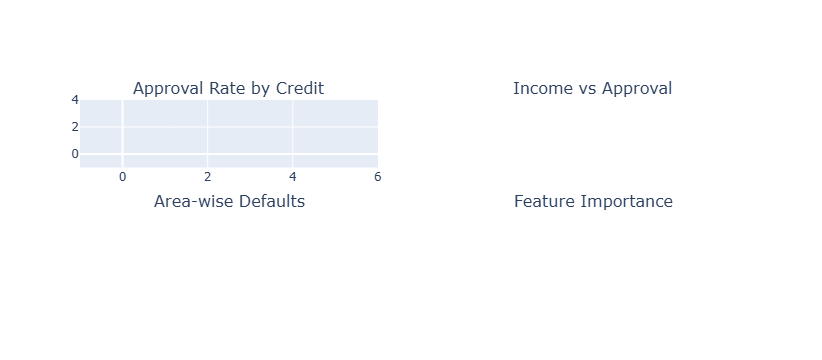

In [17]:
# 3. Executive 2x2 Dashboard
fig = make_subplots(rows=2, cols=2,
    subplot_titles=('Approval Rate by Credit', 'Income vs Approval', 
                   'Area-wise Defaults', 'Feature Importance'))
fig.write_html('credit_risk_dashboard.html')
fig.show()